<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [14]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [15]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?

In [16]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [17]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [18]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [19]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [20]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [21]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 13 max: 93 mean: 50.6 sum: 506


<b>Extra example  of why should we change int to float:</b>

In [22]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [23]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [24]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [25]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [ ]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [ ]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [ ]:
# 2) COMPILE
model.compile(
    loss="mae",
    # optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),# change to Adam for faster convergence
    metrics=["mae"]
)


model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [ ]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=0)

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [ ]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 0.194793701171875


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


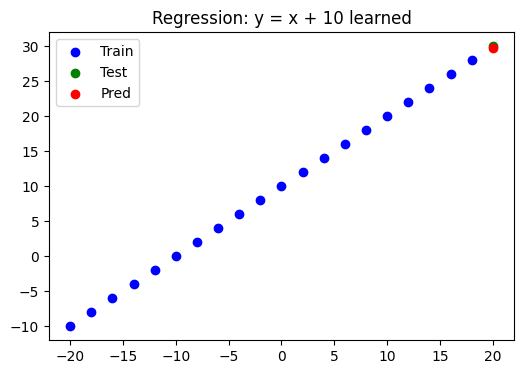

predicted values: 29.805206298828125 
test mae: 0.1948


In [ ]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

print(f'predicted values: {y_pred} ')
print(f'test mae: {mae:.4f}')

HOMEWORK: Fix the regression model

<h1>Classification</h1>

## Binary Classification Model
the task is non‑linear binary classification, so the model architecture and loss function change accordingly


sklearn is a classic machine‑learning library.
It contains tools for:
<br><br>generating datasets,preprocessing,model evaluation,classical ML algorithms.
<br><br>What is sklearn.datasets?
A module that provides:
built‑in datasets (Iris, Digits, etc.)
synthetic dataset generators (like make_circles, make_moons, make_blobs)
<br><br>What does make_circles do?
It creates a synthetic 2‑D dataset shaped like two concentric circles.
Class 0 = inner circle,
Class 1 = outer circle.
Perfect for demonstrating non‑linear classification, because a straight line cannot separate the two classes.
<br><br>Why do we import it?
Because we want to generate a dataset that requires a neural network with non‑linear layers (ReLU) to classify correctly.
<br><br>What is sklearn.model_selection?
A module that contains tools for:
splitting data,
cross‑validation,
hyperparameter search.
<br><br> What does train_test_split do?
It splits your dataset into two parts:
- Training set → used to fit the model
- Test set → used to evaluate generalization
<br><br>Why do we need it?
Because evaluating a model on the same data it was trained on does not tell you whether it learned a real pattern or just memorized the data.



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

This code generates 1000 two‑dimensional points arranged as noisy concentric circles using make_circles (with noise=0.03 adding slight randomness and random_state=42 ensuring reproducibility), and then splits the resulting inputs X and labels y into an 80% training set and a 20% test set—again with random_state=42 so the split is consistent every time—allowing the model to learn from one portion of the data and be evaluated fairly on unseen samples.


In [ ]:
# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

1) CREATE (use non-linear activations + sigmoid output)
This Sequential model is a straight stack of layers for binary classification on 2D input data.
<br><br>tf.keras.layers.Input(shape=(2,))
Defines the input shape: each sample has 2 features (for example, x and y coordinates).
<br><br>tf.keras.layers.Dense(16, activation="relu")
First hidden layer with 16 neurons and ReLU activation, helping the model learn non-linear patterns.
<br><br>tf.keras.layers.Dense(16, activation="relu")
Second hidden layer with the same setup, giving the model more capacity to learn complex decision boundaries.
<br><br>tf.keras.layers.Dense(1, activation="sigmoid")
Output layer with 1 neuron for binary classification. sigmoid returns a value between 0 and 1, interpreted as the probability of class 1.

In [ ]:
# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(...) configures how the model will learn during training.
<br><br>loss="binary_crossentropy"
Sets the loss function for binary classification.
It measures how far predicted probabilities are from true labels (0 or 1), and training tries to minimize this value.
<br><br>optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
Chooses Adam as the optimization algorithm (the rule that updates weights).
learning_rate=0.01 controls step size for each update: higher means faster but can be unstable if too large.
<br><br>metrics=["accuracy"]
Adds accuracy as a reporting metric during training/evaluation.
Accuracy shows the fraction of correct predictions, making performance easy to read.

In [ ]:
# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

<br><br>model.fit(...) runs Keras's built-in training loop to teach the model on training data.
<br><br>X_train, y_train
Pass the training inputs and labels to the model.
The model makes predictions, compares them to true labels, and adjusts weights to reduce loss.
<br><br>epochs=25
"Try the whole dataset 25 times."
Each epoch goes through all training samples once. More epochs = more learning opportunities, but too many can cause overfitting.
<br><br>verbose=0
Hides per-epoch printing output.
Use verbose=1 to see progress bars, or verbose=2 for one-line summaries per epoch.
<br><br>history = ...
Returns a History object containing per-epoch logs (loss, metrics).
You can plot history.history to visualize training progress and detect overfitting.

In [ ]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

<br><br>model.evaluate(X_test, y_test, verbose=0) runs the model on unseen test data and computes performance metrics.
<br><br>X_test, y_test
Test inputs and true labels that the model has never seen before.
Evaluating on unseen data measures generalization—whether the model learned the rule or just memorized training samples.
<br><br>verbose=0
Hides per-epoch printing.
Use verbose=1 to see progress, or verbose=2 for one-line summary.
<br><br>loss, acc = ...
Returns two values matching what you set in model.compile: [loss_value, metric_value].
Here: loss (binary_crossentropy) and acc (accuracy).
<br><br>print(f"Test accuracy: {acc:.3f}")
Prints the accuracy formatted to 3 decimal places.
High accuracy (close to 1.0) means the model predicted most test samples correctly.

In [ ]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.995


This code creates a fine grid of points covering the input space, then predicts class probabilities at each grid point to visualize the model's decision boundary.
<br><br>np.meshgrid(...)
Creates two 2D coordinate grids (xx and yy) from 1D arrays of x and y values.
Result: every (x, y) position on a 200×200 grid.
<br><br>np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200)
Creates 200 evenly-spaced x-values spanning the data range plus 10% padding on each side.
Padding ensures the boundary extends beyond the outermost data points.
<br><br>grid = np.c_[xx.ravel(), yy.ravel()]
Flattens both grids and stacks them column-wise into shape (40000, 2).
Each row is one (x, y) coordinate to predict on.
<br><br>probs = model.predict(grid, verbose=0).reshape(xx.shape)
Predicts sigmoid probabilities (0 to 1) for all 40000 grid points (verbose=0 suppresses output).
Reshapes back to (200, 200) to match the original grid for plotting.

In [ ]:
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

<br><br>plt.figure(figsize=(6,5))
Creates a blank figure with width 6 inches and height 5 inches.
Larger figure size makes the decision boundary easier to see.
<br><br>plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
Fills contoured regions with color to show the decision boundary.
<br><br>(probs>0.5).astype(int): converts probabilities to binary labels (0 or 1) using 0.5 as threshold.
<br><br>cmap=plt.cm.RdYlBu: red-yellow-blue colormap (red for class 0, blue for class 1).
<br><br>alpha=0.6: makes the filled regions semi-transparent so test points show through.
<br><br>plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
Plots the test data points as dots on top of the boundary.
<br><br>c=y_test: colors based on true labels (red for class 0, blue for class 1).
<br><br>edgecolor='k': black outlines around dots for visibility.
<br><br>plt.title("Binary classification decision boundary (non-linear)")
Labels the plot to explain what you're seeing.
<br><br>plt.show()
Displays the completed visualization.

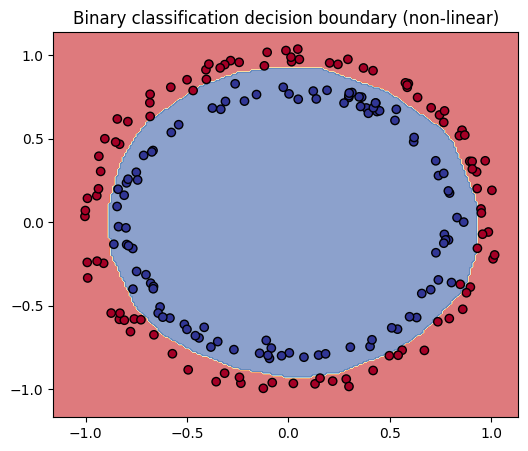

In [ ]:

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

<br><br>tf.keras.datasets.fashion_mnist.load_data()
Loads the Fashion-MNIST dataset from Keras (built-in, doesn't require downloading externally).
Fashion-MNIST is 70,000 grayscale images (28×28 pixels) of clothing items in 10 classes (shirt, shoe, bag, etc.).
<br><br>(x_train, y_train), (x_test, y_test) = ...
Unpacks the returned data into training and test sets.
<br><br>x_train: 60,000 training images, shape (60000, 28, 28), values 0–255.
<br><br>y_train: 60,000 training labels (0–9), shape (60000,).
<br><br>x_test: 10,000 test images, shape (10000, 28, 28).
<br><br>y_test: 10,000 test labels, shape (10000,).
This pre-split into train/test saves you from manually splitting and ensures fair evaluation on unseen data.

In [ ]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

<br><br>x_train.astype("float32")
Converts the integer array (uint8) to float32 dtype. This step is necessary because dividing integers by a float requires float dtype to preserve decimal precision (e.g., 127 / 255.0 = 0.498..., not rounded to 0 or 1).
<br><br>/255.0
Divides all pixel values by 255. Since pixel values range from 0–255 (8-bit unsigned integers), dividing by 255 scales them to [0.0, 1.0]. For example, 255 becomes 1.0, 128 becomes ~0.502, 0 stays 0.0.
<br><br>x_test = x_test.astype("float32")/255.0
Same operation on the test set. Both train and test must use the same normalization so the model sees consistent input ranges during evaluation.
<br><br>Why normalize?
Neural networks train better on small, normalized inputs (typically [0, 1] or [-1, 1]) because large pixel values can destabilize weight updates. Normalized data also accelerates convergence—the model learns faster on [0, 1] than on [0, 255].

In [ ]:
# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

<br><br>tf.keras.layers.Input(shape=(28, 28))
Defines the input shape: each sample is a 28×28 grayscale image. The batch dimension is implicit, so TF will handle multiple images at once.
<br><br>tf.keras.layers.Flatten()
Reshapes 2D images (28×28) into 1D vectors (784,). Flattening converts spatial structure into a single vector so Dense layers can process it. Example: a 28×28 image becomes 784 numbers in a row.
<br><br>tf.keras.layers.Dense(128, activation="relu")
Hidden layer with 128 neurons and ReLU activation. ReLU introduces non-linearity (only outputs positive values, zeros negatives), allowing the model to learn complex patterns. 128 neurons give enough capacity to capture clothing features (edges, textures, shapes).
<br><br>tf.keras.layers.Dense(10, activation="softmax")
Output layer with 10 neurons (one per clothing class: shirt, shoe, coat, etc.). Softmax converts the 10 raw outputs into probabilities that sum to 1. Example: [0.7, 0.1, 0.05, ...] means 70% confidence for class 0, 10% for class 1. The model picks the highest probability as its prediction.
<br><br>Key difference from binary classification:
Binary used Dense(1, sigmoid) for 2 classes. Multi-class uses Dense(10, softmax) for 10 classes—one neuron per class, with softmax ensuring valid probabilities across all classes.

In [ ]:
# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

<br><br>loss="sparse_categorical_crossentropy"
Loss function for multi-class classification when labels are integers (0, 1, 2, ..., 9), not one-hot encoded. "Sparse" means the labels stay as single integers; you don't convert them to [0,0,1,0,...]. This is more memory-efficient than categorical_crossentropy which expects one-hot vectors like [0,0,1,0,...]. The loss measures how far the model's 10-neuron output probabilities deviate from the true class.
<br><br>optimizer="adam"
Adam optimizer (Adaptive Moment Estimation) updates weights during training. It's a standard, fast choice that works well across most tasks. Internally, it maintains learning rates per weight and adapts them automatically—better than plain SGD for this multi-class problem.
<br><br>metrics=["accuracy"]
Tracks accuracy during training/evaluation: the fraction of predictions matching true labels. Example: if the model predicts 95 out of 100 test images correctly, accuracy = 0.95. This metric is human-readable and lets you see if the model is learning.
<br><br>Key difference from binary classification:
Binary used loss="binary_crossentropy" for outputs from 1 sigmoid neuron. Multi-class uses loss="sparse_categorical_crossentropy" for outputs from 10 softmax neurons—one per class. Dense(10, softmax) + sparse_categorical_crossentropy is the standard pairing for integer labels.

In [ ]:
# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

<br><br>model.fit(x_train, y_train, ...)
Runs Keras's built-in training loop. The model makes predictions on batches of x_train, computes sparse_categorical_crossentropy loss against y_train labels, and the optimizer (adam) updates weights to reduce that loss. Repeat for each epoch.
<br><br>epochs=10
"Try the whole dataset 10 times." Each epoch goes through all 60,000 training samples once. More epochs = more learning opportunities, but too many can cause overfitting (memorizing training data instead of learning generalizable patterns).
<br><br>validation_split=0.1
Reserve 10% of x_train/y_train (6,000 images) for validation—hold them out during weight updates but test the model on them after each epoch. This lets you monitor if the model is improving on unseen data in real-time without touching the official test set. Validation loss/accuracy help detect overfitting: if training accuracy keeps rising but validation accuracy plateaus, the model is overfitting.
<br><br>verbose=0
Hides per-epoch printing. Use verbose=1 to see progress bars, or verbose=2 for one-line summaries per epoch.
<br><br>history = ...
Returns a History object storing per-epoch logs (loss, accuracy, val_loss, val_accuracy). You can plot history.history to visualize training progress over 10 epochs.

In [ ]:
# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

<br><br>model.evaluate(X_test, y_test, verbose=0) runs the model on unseen test data and computes performance metrics.
<br><br>X_test, y_test
Test inputs and true labels that the model has never seen before.
Evaluating on unseen data measures generalization—whether the model learned the rule or just memorized training samples.
<br><br>verbose=0
Hides per-epoch printing.
Use verbose=1 to see progress, or verbose=2 for one-line summary.
<br><br>loss, acc = ...
Returns two values matching what you set in model.compile: [loss_value, metric_value].
Here: loss (binary_crossentropy) and acc (accuracy).
<br><br>print(f"Test accuracy: {acc:.3f}")
Prints the accuracy formatted to 3 decimal places.
High accuracy (close to 1.0) means the model predicted most test samples correctly.

In [ ]:
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

Test accuracy: 0.8762999773025513


<br><br>model.predict(x_test[:8])
Runs the model on the first 8 test images without updating weights. Shape: (8, 10)—8 images each get 10 softmax probabilities (one per class).
<br><br>.argmax(axis=1)
Finds the index of the highest probability for each image along axis 1 (across the 10 classes). Converts (8, 10) probabilities to (8,) class indices 0–9. Example: [0.05, 0.02, ..., 0.8, ..., 0.01] becomes 7 (the argmax index).
<br><br>preds = ...
Stores the 8 predicted class indices (e.g., [3, 5, 7, 2, 1, 9, 4, 6]).
<br><br>plt.figure(figsize=(10,3))
Creates a blank figure 10 inches wide, 3 inches tall—wide and short to fit 8 images side-by-side.
<br><br>plt.subplot(1,8,i+1)
Divides the figure into a 1×8 grid (1 row, 8 columns). Each iteration i creates a new subplot at position i+1. (i+1 because subplot numbering starts at 1, not 0.)
<br><br>plt.imshow(x_test[i], cmap='gray')
Displays the i-th test image in grayscale. Image is 28×28, values normalized to [0, 1].
<br><br>plt.title(int(preds[i]))
Adds the predicted class index (0–9) as the title above each image. int() converts from NumPy integer to Python int for clean printing.
<br><br>plt.axis('off')
Removes axis ticks and labels, keeping only the image and title—cleaner visualization.
<br><br>plt.suptitle("Predicted class indices")
Adds an overall title above all 8 subplots.
<br><br>plt.show()
Displays the completed 1×8 grid of images with their predicted class numbers as titles. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


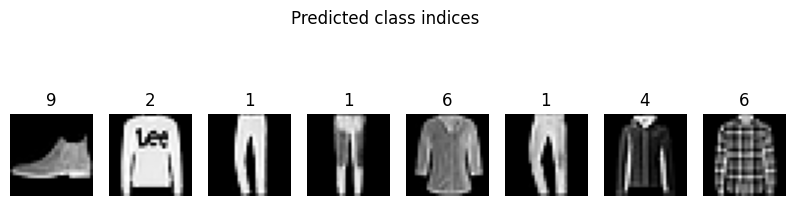

In [ ]:

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


<br><br>tf.keras.datasets.fashion_mnist.load_data()
Loads the Fashion-MNIST dataset from Keras (built-in, doesn't require downloading externally). Fashion-MNIST is 70,000 grayscale images (28×28 pixels) of clothing items in 10 classes (shirt, shoe, bag, etc.).
<br><br>(x_train, y_train), (x_test, y_test) = ...
Unpacks the returned data into training and test sets.
<br><br>x_train — 60,000 training images, shape (60000, 28, 28), values 0–255.
<br><br>y_train — 60,000 training labels (0–9), shape (60000,).
<br><br>x_test — 10,000 test images, shape (10000, 28, 28).
<br><br>y_test — 10,000 test labels, shape (10000,).
This pre-split into train/test saves it from manually splitting and ensures fair evaluation on unseen data.

In [ ]:
# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

<br><br>train_mask = np.isin(y_train, [7, 9])
Creates a boolean array of shape (60000,). Each entry is True if the label is 7 or 9, False otherwise. This marks which training samples to keep.
<br><br>test_mask = np.isin(y_test, [7, 9])
Same thing for the test set (10,000 labels).
<br><br>x_train = x_train[train_mask][..., None]/255.0
Three things at once:
<br><br>x_train[train_mask] — keeps only images where the label is 7 or 9, discarding the other 8 classes
<br><br>[..., None] — adds a channel dimension, changing shape from (N, 28, 28) → (N, 28, 28, 1), which Conv2D requires
<br><br>/255.0 — normalizes pixel values from 0–255 to 0.0–1.0
<br><br>y_train = (y_train[train_mask] == 9).astype(np.float32)
<br><br>y_train[train_mask] — keeps only labels 7 and 9
<br><br>== 9 — converts to boolean: True for Ankle boot (9), False for Sneaker (7)
<br><br>.astype(np.float32) — converts bool to float: 1.0 for Ankle boot, 0.0 for Sneaker
<br><br>x_test = x_test[test_mask][..., None]/255.0
Same preprocessing applied to test images.
<br><br>y_test = (y_test[test_mask] == 9).astype(np.float32)
Same binary label conversion applied to test labels.

In [ ]:
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

<br><br>tf.keras.Sequential([...])
Stacks layers in a linear chain — data flows top to bottom through each layer in order.
<br><br>tf.keras.layers.Input(shape=(28,28,1))
Declares the input shape: 28×28 pixel image with 1 channel (grayscale). The channel dimension was added earlier with [..., None].
<br><br>tf.keras.layers.Conv2D(16, 3, activation="relu")
Slides 16 filters of size 3×3 across the image. Each filter learns to detect a different low-level feature (edges, corners, curves). More filters = more patterns the model can recognize = better accuracy on varied inputs.
<br><br>tf.keras.layers.MaxPool2D()
Takes the max value in each 2×2 region, halving the spatial size. Helps accuracy by making the model less sensitive to exact position — a sneaker logo slightly shifted left still gets recognized.
<br><br>tf.keras.layers.Conv2D(32, 3, activation="relu")
32 filters applied to the pooled feature maps, detecting higher-level patterns like shoe outlines or boot shapes. Deeper = more abstract features = the model distinguishes the two classes more reliably.
<br><br>tf.keras.layers.MaxPool2D()
Downsamples again. Forces the model to focus on the most dominant features, discarding minor noise that could hurt generalization.
<br><br>tf.keras.layers.Flatten()
Collapses the 3D output into a 1D vector. No effect on accuracy itself — just a required format change so Dense layers can process it.
<br><br>tf.keras.layers.Dense(64, activation="relu")
Combines all spatial features into 64 abstract scores. This is where the model "decides" which combination of detected features points to Ankle boot vs Sneaker — more units = more decision capacity.
<br><br>tf.keras.layers.Dense(1, activation="sigmoid")
Single output neuron. Sigmoid squashes to (0, 1) = probability of being Ankle boot. Directly tied to accuracy — the closer this is to 1.0 for Ankle boots and 0.0 for Sneakers, the higher the accuracy.

In [ ]:
# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

<br><br>model.compile(...)
Configures the model for training — sets the rules for how it measures error, how it updates weights, and what it reports.
<br><br>loss="binary_crossentropy"
The loss function used to measure how wrong the model's predictions are. Binary crossentropy is designed for sigmoid outputs (0 or 1) — it penalizes confident wrong predictions heavily. For example, predicting 0.95 (Ankle boot) when the true label is 0 (Sneaker) gives a very high loss, pushing the model to correct hard. Lower loss = better model.
<br><br>optimizer="adam"
The algorithm that updates the model's weights after each batch to reduce the loss. Adam adapts the learning rate per parameter automatically, making it faster and more stable than basic gradient descent. It's the default go-to optimizer for most tasks.
<br><br>metrics=["accuracy"]
What gets reported during training and evaluation. Accuracy = fraction of correct predictions (e.g., 0.95 = 95% correct). This doesn't affect training — the loss does — but it gives you a human-readable number to judge how well the model is doing after each epoch

In [ ]:

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

<br><br>model.fit(...)
Runs the actual training loop — passes data through the model, computes loss, and updates weights repeatedly.
<br><br>x_train, y_train
The training images and their binary labels (0.0 = Sneaker, 1.0 = Ankle boot) fed into the model.
<br><br>epochs=5
The full training set is passed through the model 5 times. Each epoch the weights improve a little. 5 is enough here because the binary task (only 2 classes) is simpler than 10-class classification.
<br><br>validation_split=0.1
Holds out 10% of the training data (not used for weight updates) and evaluates the model on it at the end of each epoch. This tells you if the model is generalizing or just memorizing — if training accuracy keeps rising but validation accuracy stalls or drops, the model is overfitting.
<br><br>verbose=0
Silences the per-epoch progress output. Set to 1 if you want to see loss and accuracy printed each epoch.
<br><br>history = ...
Stores the training record — a dictionary of loss and accuracy values per epoch for both training and validation. You can plot history.history["accuracy"] and history.history["val_accuracy"] to visualize how learning progressed over the 5 epochs.

In [ ]:
# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

<br><br>model.evaluate(x_test, y_test, verbose=0)
Runs the model on the test set — data it has never seen during training. Returns the same metrics configured in compile(): loss and accuracy.
<br><br>verbose=0
Silences the progress bar output.
<br><br>loss, acc = ...
Unpacks the two returned values. loss is the binary crossentropy score (lower = better). acc is the fraction of correct predictions on the test set (e.g., 0.97 = 97% correct).
<br><br>print("Test accuracy:", acc)
Prints the final accuracy number. This is the most honest measure of model performance — unlike training accuracy, the model never optimized for this data, so it reflects how well it actually generalizes to new images.

In [ ]:
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

Test accuracy: 0.9745000004768372


In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras import models

<br><br>tf.keras.datasets.cifar10.load_data()
Loads the CIFAR-10 dataset from Keras (built-in, no external download needed). CIFAR-10 contains 60,000 color images (32×32 pixels, 3 RGB channels) across 10 classes — airplane, car, bird, cat, deer, dog, frog, horse, ship, truck.
<br><br>(x_train, y_train), (x_test, y_test) = ...
Unpacks into 4 variables, already pre-split:
x_train — 50,000 training images, shape (50000, 32, 32, 3), values 0–255
y_train — 50,000 training labels, shape (50000, 1) — note: CIFAR-10 labels come as a 2D column vector, unlike Fashion-MNIST which gives a 1D array
x_test — 10,000 test images, shape (10000, 32, 32, 3)
y_test — 10,000 test labels, shape (10000, 1)
<br><br>Key difference from Fashion-MNIST: images are 32×32 instead of 28×28, and have 3 color channels (RGB) instead of 1 (grayscale), making it a harder problem for the model.

In [ ]:
# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

Filters out 7 of the 10 CIFAR-10 classes, keeping only airplane (0), automobile (1), and bird (2) — turning it into a 3-class problem.
<br><br>mask_train = (y_train < 3).flatten()
y_train < 3 produces a boolean array — True where the label is 0, 1, or 2. .flatten() converts the shape from (50000, 1) to (50000,) so it can be used for indexing.
<br><br>mask_test = (y_test < 3).flatten()
Same boolean mask created for the test labels.
<br><br>x_train = x_train[mask_train].astype("float32")/255.0
x_train[mask_train] — keeps only images belonging to classes 0, 1, or 2
.astype("float32") — converts pixel values from uint8 to float32
/255.0 — normalizes pixel values from 0–255 to 0.0–1.0
<br><br>y_train = y_train[mask_train].flatten()
y_train[mask_train] — keeps only the labels 0, 1, 2
.flatten() — ensures shape is 1D (N,) rather than (N, 1), required by sparse_categorical_crossentropy
<br><br>x_test = x_test[mask_test].astype("float32")/255.0
Same normalization applied to test images.
<br><br>y_test = y_test[mask_test].flatten()
Same label flattening applied to test labels.

In [ ]:
# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

<br><br>layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3))
32 filters of size 3×3 scan the image for low-level features like edges and color gradients. padding="same" keeps the output the same spatial size as the input (32×32) by adding zeros around the border. input_shape=(32,32,3) declares the input: 32×32 RGB image with 3 color channels.
<br><br>layers.MaxPooling2D()
Halves the spatial size (32×32 → 16×16) by keeping only the max value in each 2×2 region. Reduces computation for the next layer.
<br><br>layers.Conv2D(64, (3,3), activation="relu", padding="same")
64 filters detect mid-level patterns (textures, shapes) from the pooled feature maps. More filters than the first layer because higher-level features have more variety.
<br><br>layers.MaxPooling2D()
Halves again (16×16 → 8×8).
<br><br>layers.Conv2D(128, (3,3), activation="relu", padding="same")
128 filters detect high-level features like object parts (wings, wheels, beaks). Each layer doubles the filters as spatial size shrinks — keeps the total information roughly balanced.
<br><br>layers.MaxPooling2D()
Halves again (8×8 → 4×4).
<br><br>layers.Flatten()
Collapses 4×4×128 = 2048 values into a 1D vector for the Dense layers.
<br><br>layers.Dense(64, activation="relu")
Combines all 2048 spatial features into 64 abstract scores to make the final class decision.
<br><br>layers.Dense(3, activation="softmax")
3 output neurons — one per class (airplane, automobile, bird). Softmax converts raw scores into probabilities that sum to 1.0. The class with the highest probability is the prediction.

In [ ]:
# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)),
     # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

c:\Users\zxcv0\miniforge3\envs\ryzen-ai-1.5.1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<br><br>model.compile(...)
Configures the model for training — sets how it measures error, how it updates weights, and what it reports.
<br><br>optimizer="adam"
Adam automatically adjusts the learning rate for each weight during training, making it faster and more stable than basic gradient descent. It's the standard default for most deep learning tasks.
<br><br>loss="sparse_categorical_crossentropy"
The loss function for multi-class problems where labels are integers (0, 1, 2) rather than one-hot vectors. "Sparse" means it accepts raw integer labels directly — no need to convert them. It measures how far the softmax probabilities are from the correct class, penalizing confident wrong predictions heavily.
<br><br>metrics=["accuracy"]
Tracks and reports accuracy during training and evaluation — the fraction of images correctly classified out of the total. This doesn't affect weight updates (only loss does), but gives a human-readable measure of progress each epoch.

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

<br><br>model.fit(...)
Runs the training loop — feeds data through the model, computes loss, and updates weights repeatedly.
<br><br>x_train, y_train
The training images (normalized RGB arrays) and their integer labels (0=airplane, 1=automobile, 2=bird).
<br><br>epochs=5
The full training set is passed through the model 5 times. Each epoch the weights improve a little as the model learns to distinguish the 3 classes.
<br><br>batch_size=64
Instead of updating weights after every single image, 64 images are processed together before each weight update. Larger batches = more stable gradient estimates. This is new compared to the binary CNN, which used the default batch size of 32.
<br><br>validation_split=0.1
Holds out 10% of training data to evaluate the model at the end of each epoch without using it for weight updates. Lets you monitor whether the model is generalizing or overfitting — if training accuracy rises but validation accuracy stalls, the model is memorizing.
<br><br>verbose=1
Prints a progress bar with loss and accuracy for both training and validation after each epoch. Unlike the binary CNN (verbose=0), here you can watch the model improve in real time.
<br><br>history = ...
Stores all loss and accuracy values per epoch. You can later plot history.history["accuracy"] vs history.history["val_accuracy"] to visualize the learning curve.

In [ ]:
# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7187 - loss: 0.6558 - val_accuracy: 0.8080 - val_loss: 0.4695
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8304 - loss: 0.4208 - val_accuracy: 0.8553 - val_loss: 0.3703
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8667 - loss: 0.3383 - val_accuracy: 0.8953 - val_loss: 0.2975
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8916 - loss: 0.2788 - val_accuracy: 0.9027 - val_loss: 0.2779
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9024 - loss: 0.2536 - val_accuracy: 0.9060 - val_loss: 0.2683


<br><br>loss, acc means loss and accuracy on the test set
<br><br>model.evaluate returns the loss and metrics specified in model.compile
<br><br>x_test and y_test are the test data and labels
<br><br>verbose=0 means no progress bar during evaluation

In [ ]:

# --- Evaluate ---

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


Test accuracy (tiny CNN): 0.8933333158493042


Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


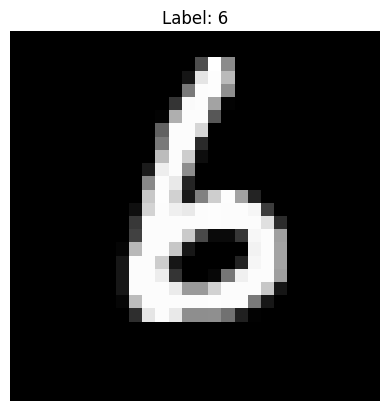


Testing optimizer: adam


c:\Users\zxcv0\Desktop\ML\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train Acc: 0.981
Val Acc:   0.973
Test Acc:  0.975

Testing optimizer: sgd
Train Acc: 0.910
Val Acc:   0.918
Test Acc:  0.917

Testing optimizer: rmsprop
Train Acc: 0.980
Val Acc:   0.972
Test Acc:  0.974

Testing optimizer: adagrad
Train Acc: 0.867
Val Acc:   0.881
Test Acc:  0.881


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9072 - loss: 0.3325 - val_accuracy: 0.9504 - val_loss: 0.1818
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9562 - loss: 0.1493 - val_accuracy: 0.9642 - val_loss: 0.1273
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9698 - loss: 0.1043 - val_accuracy: 0.9684 - val_loss: 0.1117
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9770 - loss: 0.0788 - val_accuracy: 0.9707 - val_loss: 0.1001
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9819 - loss: 0.0625 - val_accuracy: 0.9718 - val_loss: 0.0952


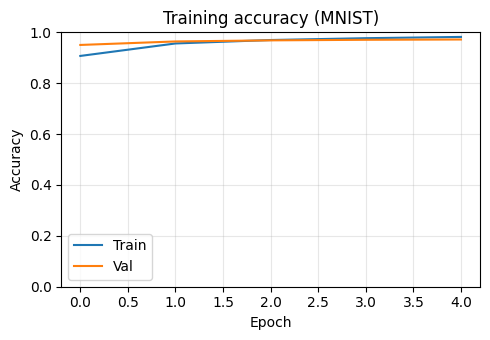

Test accuracy: 0.974
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


NameError: name 'Image' is not defined

In [ ]:
import keras
from keras.datasets import mnist
from keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import layers, models
from IPython.display import Image, display
# --- Load MNIST ---
# mnist.load_data() loads the MNIST handwritten digit dataset.
# It returns:
#   x_train: 60,000 training images, shape (60000, 28, 28)
#   y_train: 60,000 labels (digits 0–9)
#   x_test:  10,000 test images
#   y_test:  10,000 test labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Convert pixel values from integers [0,255] to floats [0,1].
# Normalization helps the model train faster and more stably.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)


# --- Show ONE random image ---
# This function displays one random MNIST image from the dataset.
# It helps visually confirm that the data loaded correctly.
def show_one_example(X, y):
    i = np.random.randint(len(X))          # pick a random index
    plt.imshow(X[i], cmap="gray", vmin=0, vmax=1)  # show grayscale image
    plt.title(f"Label: {y[i]}")            # show the true digit label
    plt.axis("off")                        # hide axes for cleaner display
    plt.show()

show_one_example(x_train, y_train)



# Function: Check optimizer vs accuracy 
# This function rebuilds the same MNIST model, trains it using
# a specified optimizer, and reports:
# final training accuracy
# final validation accuracy
# test accuracy
# This allows comparing how different optimizers affect performance.
def check_optimizer(opt_name):
    # Train the MNIST MLP model using a specific optimizer
    # and report training, validation, and test accuracy.
    # opt_name: string or optimizer instance,"adam", "sgd", "rmsprop".
    # Print which optimizer is being tested.
    # This makes the console output easier to read when testing multiple optimizers.
    print(f"\nTesting optimizer: {opt_name}")

    # Rebuild the same model architecture each time:
    # We must create a NEW model for every optimizer, otherwise
    # the weights from a previous run would affect the results.
    model = keras.Sequential([
        # Flatten: convert 28×28 image into a 784‑dimensional vector.
        layers.Flatten(input_shape=(28, 28)),
        # Hidden layer: 128 neurons with ReLU activation.
        layers.Dense(128, activation="relu"),
        # Output layer: 10 neurons with softmax for 10 digit classes (0–9).
        layers.Dense(10, activation="softmax")
    ])

    # Compile the model with the chosen optimizer:
    # optimizer=opt_name → this is what we are comparing.
    # loss="sparse_categorical_crossentropy" → correct for integer labels.
    # metrics=["accuracy"] → we care about accuracy as the main metric.
    model.compile(
        optimizer=opt_name,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model:
    # x_train, y_train are the global MNIST training data.
    # epochs=5 → train for 5 passes over the training set.
    # batch_size=64 → update weights after every 64 samples.
    # validation_split=0.2 → use 20% of training data as validation set.
    # verbose=0 → no progress bar, cleaner output when testing many optimizers.
    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate on the test set:
    # x_test, y_test are unseen data, used to measure generalization.
    # model.evaluate() returns loss and accuracy.
    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    # Print final metrics:
    # history.history["accuracy"][-1] → last epoch's training accuracy.
    # history.history["val_accuracy"][-1] → last epoch's validation accuracy.
    # acc → test accuracy on unseen data.
    print(f"Train Acc: {history.history['accuracy'][-1]:.3f}")
    print(f"Val Acc:   {history.history['val_accuracy'][-1]:.3f}")
    print(f"Test Acc:  {acc:.3f}")

    # Return test accuracy so it can be stored or compared later.
    return acc


# --- Test several optimizers ---
# This block runs the above function for multiple optimizers
# to compare their performance on MNIST.
optimizers = ["adam", "sgd", "rmsprop", "adagrad"]
for opt in optimizers:
    check_optimizer(opt)


# --- Model ---
# Build a simple MLP (Multi-Layer Perceptron) classifier:
# 1. Flatten: convert 28×28 image → 784‑dimensional vector
# 2. Dense(128, relu): hidden layer with 128 neurons
# 3. Dense(10, softmax): output probabilities for 10 digit classes
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # reshape input to (None, 784)
    layers.Dense(128, activation="relu"),   # fully connected hidden layer
    layers.Dense(10, activation="softmax")  # output layer for 10 classes
])

# Compile the model:
# optimizer="adam" → adaptive optimizer, good default choice
# loss="sparse_categorical_crossentropy" → correct for integer labels
# metrics=["accuracy"] → track accuracy during training/testing
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model architecture summary:
# Shows each layer, output shape, and number of trainable parameters.
model.summary()


# --- Train ---
# Train the model on the training data:
# epochs=5 → train for 5 passes over the dataset
# batch_size=64 → update weights after every 64 samples
# validation_split=0.2 → use 20% of training data for validation
# verbose=1 → show progress bar and metrics
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# --- Accuracy plot ---
# Plot training accuracy and validation accuracy over epochs.
# This helps visualize learning progress and detect overfitting.
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")        # training accuracy
plt.plot(history.history["val_accuracy"], label="Val")      # validation accuracy
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (MNIST)")
plt.tight_layout()
plt.show()


# --- Evaluate ---
# Evaluate the trained model on the test set (unseen data).
# model.evaluate() returns:
#   loss → test loss
#   acc  → test accuracy
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")


# --- Model diagram ---
# plot_model() generates a visual diagram of the model architecture.
# to_file="model_mnist.png" saves the diagram as a PNG image.
plot_model(
    model,
    to_file="model_mnist.png"
)

# Display the saved model diagram inside the notebook.
display(Image("model_mnist.png"))

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)

Testing optimizer: adam
Train Acc: 0.982
Val Acc:   0.969
Test Acc:  0.971

Testing optimizer: sgd
Train Acc: 0.911
Val Acc:   0.917
Test Acc:  0.920

Testing optimizer: rmsprop
Train Acc: 0.982
Val Acc:   0.969
Test Acc:  0.969

Testing optimizer: adagrad
Train Acc: 0.868
Val Acc:   0.883
Test Acc:  0.883


Model: "parallel_mlp_mnist"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 128)       │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      1,290 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9062 - loss: 0.3311 - val_accuracy: 0.9496 - val_loss: 0.1782
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9557 - loss: 0.1510 - val_accuracy: 0.9594 - val_loss: 0.1354
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9694 - loss: 0.1049 - val_accuracy: 0.9643 - val_loss: 0.1193
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9766 - loss: 0.0791 - val_accuracy: 0.9671 - val_loss: 0.1094
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9825 - loss: 0.0617 - val_accuracy: 0.9683 - val_loss: 0.1045


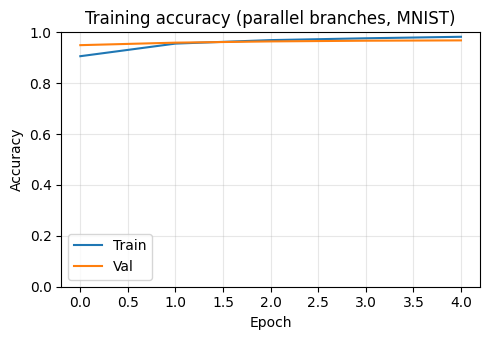

Test accuracy: 0.970
You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'parallel_mlp.png'

FileNotFoundError: No such file or directory: 'parallel_mlp.png'

<IPython.core.display.Image object>

In [ ]:
# --- Load & prep MNIST ---
# mnist.load_data() loads the MNIST handwritten digit dataset.
# It returns:
#   x_train: 60,000 training images, shape (60000, 28, 28)
#   y_train: 60,000 labels (digits 0–9)
#   x_test:  10,000 test images
#   y_test:  10,000 test labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values from [0,255] to [0,1].
# Normalization improves training stability and convergence speed.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)


# --- Function: Compare optimizer vs. accuracy ---
# This function rebuilds the same parallel‑branch MLP model,
# trains it using a specified optimizer, and reports:
#   - final training accuracy
#   - final validation accuracy
#   - final test accuracy
# This allows you to compare how different optimizers affect performance.
def check_optimizer(opt_name):
    print(f"\nTesting optimizer: {opt_name}")

    # Rebuild the same model architecture so each optimizer starts fresh.
    inputs = keras.Input(shape=(28, 28), name="input")
    x = layers.Flatten(name="flatten")(inputs)

    # Branch A
    branch_a = layers.Dense(64, activation="relu", name="branchA_dense")(x)

    # Branch B
    branch_b = layers.Dense(64, activation="relu", name="branchB_dense")(x)

    # Merge both branches
    merged = layers.Concatenate(name="concat")([branch_a, branch_b])

    # Output layer: 10‑class softmax
    outputs = layers.Dense(10, activation="softmax", name="output")(merged)

    # Build the model
    model = keras.Model(inputs, outputs, name=f"parallel_mlp_{opt_name}")

    # Compile using the optimizer being tested
    model.compile(
        optimizer=opt_name,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model quietly (verbose=0)
    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate on the test set
    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    # Print results
    print(f"Train Acc: {history.history['accuracy'][-1]:.3f}")
    print(f"Val Acc:   {history.history['val_accuracy'][-1]:.3f}")
    print(f"Test Acc:  {acc:.3f}")

    return acc

optimizers = ["adam", "sgd", "rmsprop", "adagrad"]
# This loop runs the optimizer comparison function for multiple
# optimizers to observe differences in performance.

for opt in optimizers:
    check_optimizer(opt)

# --- Parallel-branches MLP (Functional API) ---
# This model uses the Functional API to create two parallel Dense branches.
# Architecture:
#   Input → Flatten → Branch A + Branch B → Concatenate → Output layer

inputs = keras.Input(shape=(28, 28), name="input")   # Input layer for 28×28 images
x = layers.Flatten(name="flatten")(inputs)           # Flatten to a 784‑dim vector

# Branch A: first Dense pathway
branch_a = layers.Dense(64, activation="relu", name="branchA_dense")(x)

# Branch B: second Dense pathway
branch_b = layers.Dense(64, activation="relu", name="branchB_dense")(x)

# Merge the two branches by concatenating their outputs
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output layer: 10‑class softmax for MNIST digit classification
outputs = layers.Dense(10, activation="softmax", name="output")(merged)

# Build the full model object
model = keras.Model(inputs, outputs, name="parallel_mlp_mnist")

# Compile the model:
# optimizer="adam" → adaptive optimizer, strong default choice
# loss="sparse_categorical_crossentropy" → correct for integer labels
# metrics=["accuracy"] → track accuracy during training and evaluation
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()   # Print the architecture, showing both branches


# --- Train ---
# Train the model:
# epochs=5 → train for 5 full passes over the dataset
# batch_size=64 → update weights every 64 samples
# validation_split=0.2 → use 20% of training data for validation
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# --- Plot accuracy ---
# Plot training and validation accuracy curves to visualize learning progress.
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")        # Training accuracy
plt.plot(history.history["val_accuracy"], label="Val")      # Validation accuracy
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches, MNIST)")
plt.tight_layout()
plt.show()


# --- Evaluate on test set ---
# Evaluate the trained model on unseen test data.
# model.evaluate() returns:
#   loss → test loss
#   acc  → test accuracy
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")


# --- Model diagram ---
# plot_model() generates a visual diagram of the model architecture.
# to_file="parallel_mlp.png" saves the diagram as a PNG image.
plot_model(
    model,
    to_file="parallel_mlp.png"
)

# Display the saved model diagram inside the notebook.
display(Image("parallel_mlp.png"))



In [ ]:
import os

# --- Load & prep MNIST ---
# mnist.load_data() loads the MNIST handwritten digit dataset.
# It returns:
#   x_train: 60,000 training images (28×28)
#   y_train: 60,000 labels (digits 0–9)
#   x_test:  10,000 test images
#   y_test:  10,000 test labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Convert pixel values from integers [0,255] to floats [0,1].
# Normalization improves training stability and speeds up convergence.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)

# --- Function: Compare optimizer vs. accuracy ---
# This function rebuilds the same MLP model, trains it using a specified
# optimizer, and reports:
#   - final training accuracy
#   - final validation accuracy
#   - final test accuracy
# This allows comparing how different optimizers affect performance.
def check_optimizer(opt_name):
    print(f"\nTesting optimizer: {opt_name}")

    # Rebuild the same model architecture so each optimizer starts fresh.
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),   # flatten 28×28 → 784
        layers.Dense(128, activation="relu"),   # hidden layer
        layers.Dense(10, activation="softmax")  # output layer
    ])

    # Compile using the optimizer being tested.
    model.compile(
        optimizer=opt_name,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model quietly (verbose=0).
    history = model.fit(
        x_train, y_train,
        epochs=6,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate on the test set.
    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    # Print results.
    print(f"Train Acc: {history.history['accuracy'][-1]:.3f}")
    print(f"Val Acc:   {history.history['val_accuracy'][-1]:.3f}")
    print(f"Test Acc:  {acc:.3f}")

    return acc
optimizers = ["adam", "sgd", "rmsprop", "adagrad"]

for opt in optimizers:
    check_optimizer(opt)

# --- MLP model ---
# A simple fully connected neural network for MNIST classification.
# Architecture:
#   Flatten → Dense(128, relu) → Dense(10, softmax)
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # flattens 28×28 → 784‑dim vector
    layers.Dense(128, activation="relu"),  # hidden layer with 128 neurons
    layers.Dense(10, activation="softmax") # output layer for 10 digit classes
])

# Compile the model:
# optimizer="adam" → adaptive optimizer, strong default choice
# loss="sparse_categorical_crossentropy" → correct for integer labels
# metrics=["accuracy"] → track accuracy during training/testing
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


# --- Train ---
# Train the model on the training data:
# epochs=6 → train for 6 full passes over the dataset
# batch_size=32 → update weights every 32 samples
# validation_split=0.2 → use 20% of training data for validation
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# --- Evaluate ---
# Evaluate the trained model on the test set (unseen data).
# model.evaluate() returns:
#   loss → test loss
#   acc  → test accuracy
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")


# --- Save to a .keras file ---
# model.save() stores:
#   - model architecture
#   - trained weights
#   - optimizer state
#   - training configuration
# The saved file can be loaded later with keras.models.load_model().
save_path = "miras_model.keras"
model.save(save_path)

# Print the absolute path so you know exactly where the file is stored.
print("Saved model to:", os.path.abspath(save_path))

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)

Testing optimizer: adam
Train Acc: 0.990
Val Acc:   0.970
Test Acc:  0.970

Testing optimizer: sgd
Train Acc: 0.932
Val Acc:   0.939
Test Acc:  0.938

Testing optimizer: rmsprop
Train Acc: 0.987
Val Acc:   0.968
Test Acc:  0.968

Testing optimizer: adagrad
Train Acc: 0.890
Val Acc:   0.902
Test Acc:  0.900
Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9180 - loss: 0.2847 - val_accuracy: 0.9524 - val_loss: 0.1662
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9615 - loss: 0.1289 - val_accuracy: 0.9601 - val_loss: 0.1348
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9740 - loss: 0.0884 - val_accuracy: 0.9636 - val_loss: 0.1214
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9813 - loss: 0.0646 - val_accuracy: 0.9647 - val_loss: 0.1183
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9866 - loss: 0.0480 - val_accuracy: 0.9659 -

In [ ]:
# --- Load & prep MNIST (same dataset as your training cell) ---
# We only need the test set here because:
#   - the model has already been trained and saved
#   - we now want to evaluate the saved model on unseen data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize test images to [0,1] just like during training.
# IMPORTANT: The preprocessing must match the training phase.
x_test = x_test.astype("float32") / 255.0

print("Test:", x_test.shape, y_test.shape)  # (10000, 28, 28), (10000,)


# --- Load the saved .keras model ---
# keras.saving.load_model() restores:
#   - model architecture
#   - trained weights
#   - optimizer state (if saved)
#   - training configuration
# The loaded model behaves exactly like the original one.
loaded_model = keras.saving.load_model("miras_model.keras")

# Print the architecture to confirm it loaded correctly.
loaded_model.summary()


# --- Evaluate the loaded model on MNIST test ---
# Evaluate on unseen test data to verify that:
#   - the saved model works correctly
#   - accuracy matches the original model before saving
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")


# --- Predict a few samples ---
# loaded_model.predict() outputs class probabilities for each image.
# For MNIST:
#   - input shape: (N, 28, 28)
#   - output shape: (N, 10) → probability for each digit 0–9
probs = loaded_model.predict(x_test[:5], verbose=0)

# Convert probability vectors to predicted class labels.
preds = probs.argmax(axis=1)

print("Predictions:", preds.tolist())       # model's predicted digits
print("True labels:", y_test[:5].tolist())  # actual digits

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]
